In [2]:
# ============================================================
# BLOCK 1: Environment Setup & Imports
# CRISP-DM Phase: Business Understanding / Setup
# ============================================================

# Install required libraries (run once)
# !pip install numpy pandas matplotlib seaborn scipy scikit-learn
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install pywavelets shap tqdm

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import scipy.signal as signal
import scipy.stats as stats
import pywt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import shap

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Lambda utility functions (reused throughout notebook) ─────
rms          = lambda x: np.sqrt(np.mean(x**2))
variance_fn  = lambda x: np.var(x)
kurtosis_fn  = lambda x: stats.kurtosis(x)
skewness_fn  = lambda x: stats.skew(x)
crest_fn     = lambda x: np.max(np.abs(x)) / (rms(x) + 1e-10)
peak_fn      = lambda x: np.max(np.abs(x))
ppv_fn       = lambda x: np.max(x) - np.min(x)           # peak-to-peak value
shape_fn     = lambda x: rms(x) / (np.mean(np.abs(x)) + 1e-10)
impulse_fn   = lambda x: peak_fn(x) / (np.mean(np.abs(x)) + 1e-10)
clearance_fn = lambda x: peak_fn(x) / (np.mean(np.sqrt(np.abs(x))) + 1e-10)**2
margin_fn    = lambda x: peak_fn(x) / (np.mean(np.abs(x))**2 + 1e-10)

fft_peak2peak = lambda x: np.max(np.abs(np.fft.rfft(x))) - np.min(np.abs(np.fft.rfft(x)))
fft_energy    = lambda x: np.sum(np.abs(np.fft.rfft(x))**2)
psd_fn        = lambda x, fs=25600: np.sum(signal.welch(x, fs=fs, nperseg=256)[1])

add_noise     = lambda x, sigma: x + np.random.normal(0, sigma, x.shape)
pct_error     = lambda actual, pred: 100 * (actual - pred) / (actual + 1e-10)

print("Lambda utilities registered.")
print(f"Torch version: {torch.__version__} | NumPy: {np.__version__}")

C:\Users\Vinay Sankar\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Lambda utilities registered.
Torch version: 2.11.0+cu128 | NumPy: 2.2.6


In [3]:
# ============================================================
# BLOCK 2: Data Loading — PRONOSTIA Dataset
# CRISP-DM Phase: Data Understanding
# ============================================================
# Expected folder structure:
#   PRONOSTIA/
#     Learning_set/
#       Bearing1_1/  acc_00001.csv  ...
#       Bearing1_2/  ...
#     Test_set/
#       Bearing1_3/  ...
# ── Set your root path ───────────────────────────────────────

DATA_ROOT = Path("C:\IAI Second Semesetr\B5\Mini Project 2\RUL-Prediction-Pronostia-Dataset-master\RUL-Prediction-Pronostia-Dataset-master")   # <-- change to your path

FS        = 25600    # vibration sampling frequency (Hz)
N_SAMPLES = 2560     # samples per recording window (1/10 s)

# ── File parser ───────────────────────────────────────────────
def load_bearing(bearing_path: Path) -> pd.DataFrame:
    """Load all acc_*.csv files for one bearing into a DataFrame.
    Columns: hour, minute, second, microsecond, horiz_acc, vert_acc
    Adds: window_id, time_s (elapsed seconds from first window)
    """
    files = sorted(bearing_path.glob("acc_*.csv"))
    if not files:
        raise FileNotFoundError(f"No acc_*.csv in {bearing_path}")

    frames = []
    for i, fp in enumerate(files):
        df = pd.read_csv(fp, header=None,
                         names=["hour","minute","second","microsecond",
                                "horiz_acc","vert_acc"])
        df["window_id"] = i
        frames.append(df)

    data = pd.concat(frames, ignore_index=True)
    # elapsed seconds: each file = 1 window = 0.1 s recording every 10 s
    data["time_s"] = data["window_id"] * 10
    return data

# ── Discover all bearings ─────────────────────────────────────
def discover_bearings(root: Path) -> dict:
    """Return dict: {bearing_name: (path, split)} """
    bearings = {}
    for split in ["Learning_set", "Test_set"]:
        split_path = root / split
        if not split_path.exists():
            continue
        for bp in sorted(split_path.iterdir()):
            if bp.is_dir():
                bearings[bp.name] = {"path": bp, "split": split}
    return bearings

bearing_index = discover_bearings(DATA_ROOT)
print(f"Found {len(bearing_index)} bearings:")
for name, meta in bearing_index.items():
    files = list(meta["path"].glob("acc_*.csv"))
    print(f"  {name:15s} | {meta['split']:14s} | {len(files):4d} windows")

Found 17 bearings:
  Bearing1_1      | Learning_set   | 2803 windows
  Bearing1_2      | Learning_set   |  871 windows
  Bearing2_1      | Learning_set   |  911 windows
  Bearing2_2      | Learning_set   |  797 windows
  Bearing3_1      | Learning_set   |  515 windows
  Bearing3_2      | Learning_set   | 1637 windows
  Bearing1_3      | Test_set       | 1802 windows
  Bearing1_4      | Test_set       | 1139 windows
  Bearing1_5      | Test_set       | 2302 windows
  Bearing1_6      | Test_set       | 2302 windows
  Bearing1_7      | Test_set       | 1502 windows
  Bearing2_3      | Test_set       | 1202 windows
  Bearing2_4      | Test_set       |  612 windows
  Bearing2_5      | Test_set       | 2002 windows
  Bearing2_6      | Test_set       |  572 windows
  Bearing2_7      | Test_set       |  172 windows
  Bearing3_3      | Test_set       |  352 windows


Computing stats: 100%|█████████████████████████████████████████████████████████████████| 17/17 [07:05<00:00, 25.02s/it]


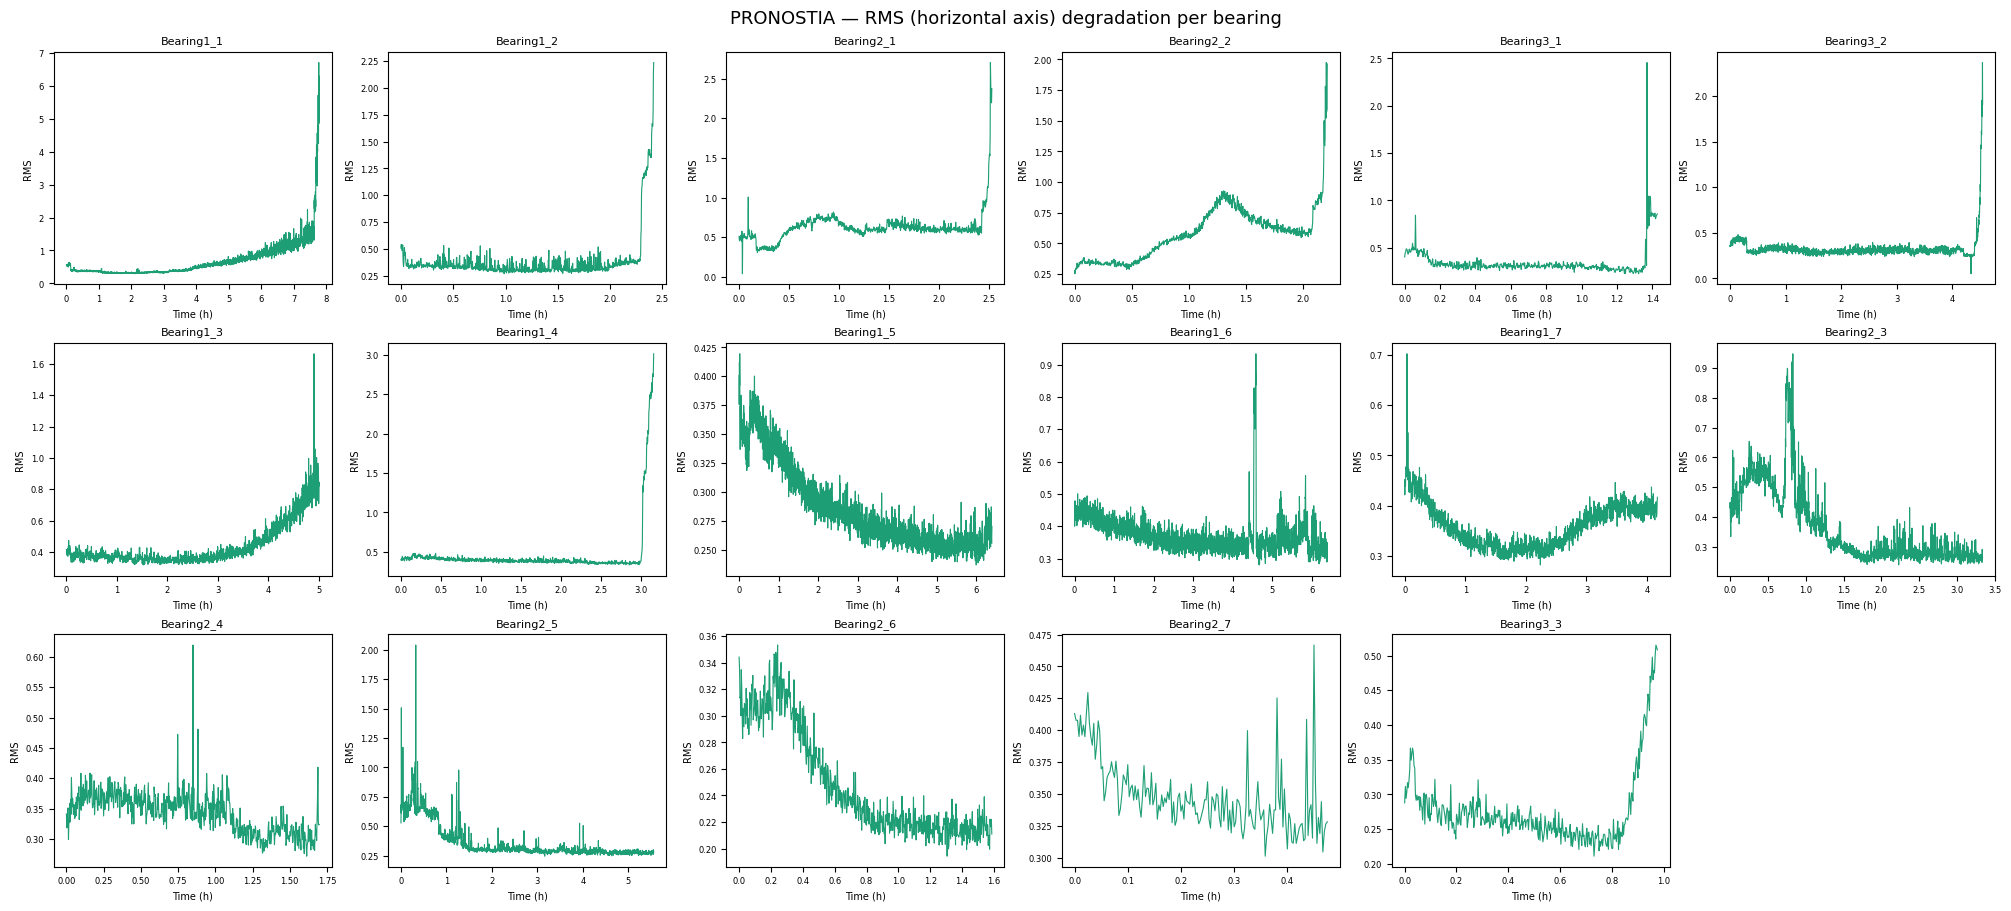

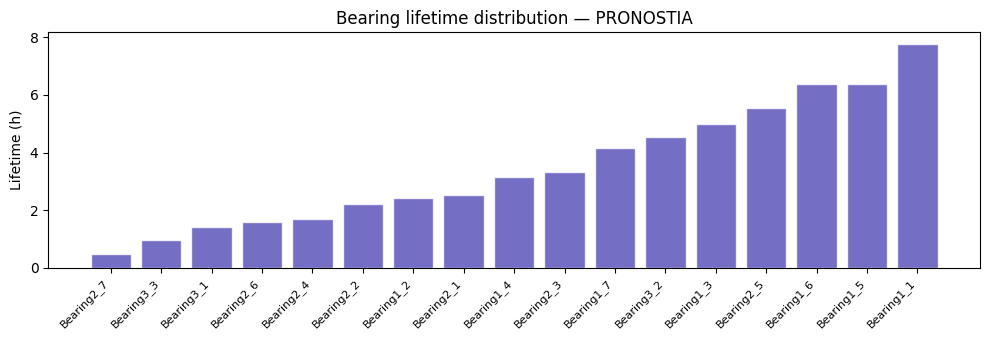


Lifetime stats:
  Min:  0.47 h
  Max:  7.78 h
  Mean: 3.51 h
  Std:  2.15 h


In [4]:
# ============================================================
# BLOCK 3: Exploratory Data Analysis
# CRISP-DM Phase: Data Understanding
# ============================================================

def compute_window_stats(bearing_path: Path) -> pd.DataFrame:
    """Compute per-window RMS and kurtosis for both axes."""
    files = sorted(bearing_path.glob("acc_*.csv"))
    records = []
    for i, fp in enumerate(files):
        df = pd.read_csv(fp, header=None,
                         names=["hour","minute","second","microsecond",
                                "horiz_acc","vert_acc"])
        h, v = df["horiz_acc"].values, df["vert_acc"].values
        records.append({
            "window_id": i,
            "time_s":    i * 10,
            "rms_h":     rms(h),   "rms_v":     rms(v),
            "kurt_h":    kurtosis_fn(h), "kurt_v": kurtosis_fn(v),
        })
    return pd.DataFrame(records)

# ── Compute stats for all bearings ───────────────────────────
all_stats = {}
for name, meta in tqdm(bearing_index.items(), desc="Computing stats"):
    all_stats[name] = compute_window_stats(meta["path"])

# ── Plot: RMS degradation curves ─────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(20, 9), constrained_layout=True)
fig.suptitle("PRONOSTIA — RMS (horizontal axis) degradation per bearing", fontsize=13)

for ax, (name, df) in zip(axes.flat, all_stats.items()):
    ax.plot(df["time_s"] / 3600, df["rms_h"], lw=0.8, color="#1D9E75")
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("Time (h)", fontsize=7)
    ax.set_ylabel("RMS", fontsize=7)
    ax.tick_params(labelsize=6)

# Hide unused subplots
for ax in axes.flat[len(all_stats):]:
    ax.set_visible(False)

plt.savefig("eda_rms_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Lifetime distribution ─────────────────────────────────────
lifetimes = {
    name: df["time_s"].max() / 3600
    for name, df in all_stats.items()
}
lt_series = pd.Series(lifetimes).sort_values()

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(lt_series.index, lt_series.values, color="#534AB7", alpha=0.8, edgecolor="white")
ax.set_ylabel("Lifetime (h)")
ax.set_title("Bearing lifetime distribution — PRONOSTIA")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("eda_lifetimes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLifetime stats:")
print(f"  Min:  {lt_series.min():.2f} h")
print(f"  Max:  {lt_series.max():.2f} h")
print(f"  Mean: {lt_series.mean():.2f} h")
print(f"  Std:  {lt_series.std():.2f} h")

Loading AE data: 100%|███████████████████████████████████████████████████████████████████| 6/6 [00:27<00:00,  4.55s/it]


AE training data shape: torch.Size([75340, 256, 1])


AE training: 100%|██████████████████████████████████████████████████████████████████| 20/20 [5:04:43<00:00, 914.18s/it]


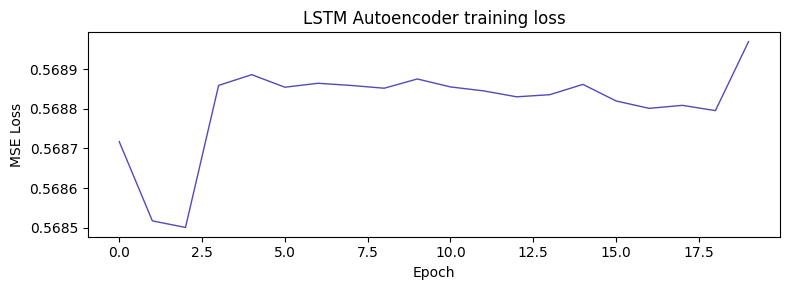

Autoencoder saved.


In [5]:
# ============================================================
# BLOCK 4: LSTM Autoencoder — Noise Filtering
# CRISP-DM Phase: Data Preparation
# ============================================================

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=1, hidden1=512, hidden2=64, seq_len=256):
        super().__init__()
        self.seq_len = seq_len

        # Encoder
        self.enc_lstm1 = nn.LSTM(input_size, hidden1, batch_first=True)
        self.enc_relu1 = nn.ReLU()
        self.enc_drop1 = nn.Dropout(0.2)
        self.enc_lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.enc_relu2 = nn.ReLU()
        self.enc_drop2 = nn.Dropout(0.2)

        # Decoder (mirrors encoder)
        self.dec_lstm1 = nn.LSTM(hidden2, hidden2, batch_first=True)
        self.dec_relu1 = nn.ReLU()
        self.dec_drop1 = nn.Dropout(0.2)
        self.dec_lstm2 = nn.LSTM(hidden2, hidden1, batch_first=True)
        self.dec_relu2 = nn.ReLU()
        self.dec_drop2 = nn.Dropout(0.2)
        self.output_layer = nn.Linear(hidden1, input_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.enc_lstm1(x)
        out = self.enc_drop1(self.enc_relu1(out))
        out, (hidden, _) = self.enc_lstm2(out)
        out = self.enc_drop2(self.enc_relu2(out))

        # Repeat vector: use last hidden state across all timesteps
        repeated = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)

        out, _ = self.dec_lstm1(repeated)
        out = self.dec_drop1(self.dec_relu1(out))
        out, _ = self.dec_lstm2(out)
        out = self.dec_drop2(self.dec_relu2(out))
        return self.output_layer(out)


def prepare_ae_data(bearing_path: Path, seq_len: int = 256,
                    scaler=None, fit_scaler: bool = True):
    """Segment raw vibration windows into seq_len sub-sequences for AE training."""
    files = sorted(bearing_path.glob("acc_*.csv"))
    segments = []
    for fp in files:
        df = pd.read_csv(fp, header=None,
                         names=["hour","minute","second","microsecond",
                                "horiz_acc","vert_acc"])
        sig = df["horiz_acc"].values.astype(np.float32)
        # split into non-overlapping segments
        for start in range(0, len(sig) - seq_len + 1, seq_len):
            segments.append(sig[start:start+seq_len])

    X = np.array(segments, dtype=np.float32)  # (N, seq_len)

    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_flat = X.reshape(-1, 1)
        scaler.fit(X_flat)
    X = scaler.transform(X.reshape(-1, 1)).reshape(X.shape)
    X = X[:, :, np.newaxis]  # (N, seq_len, 1)
    return torch.tensor(X, dtype=torch.float32), scaler


def train_autoencoder(ae_model, data_tensor, epochs=20, batch_size=16, lr=1e-3):
    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(ae_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    ae_model.train()
    losses = []
    for ep in tqdm(range(epochs), desc="AE training"):
        ep_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            recon = ae_model(batch)
            loss  = criterion(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        losses.append(ep_loss / len(loader))
    return losses


def denoise_bearing(ae_model, bearing_path: Path, scaler,
                    seq_len: int = 256) -> np.ndarray:
    """Return full denoised signal (all windows concatenated) as 1D array."""
    files = sorted(bearing_path.glob("acc_*.csv"))
    denoised_windows = []
    ae_model.eval()
    with torch.no_grad():
        for fp in files:
            df = pd.read_csv(fp, header=None,
                             names=["hour","minute","second","microsecond",
                                    "horiz_acc","vert_acc"])
            sig = df["horiz_acc"].values.astype(np.float32)
            segments, leftovers = [], []
            for start in range(0, len(sig) - seq_len + 1, seq_len):
                segments.append(sig[start:start+seq_len])
            if segments:
                X = np.array(segments, dtype=np.float32)
                X = scaler.transform(X.reshape(-1,1)).reshape(X.shape)
                X_t = torch.tensor(X[:,:,np.newaxis], dtype=torch.float32).to(DEVICE)
                recon = ae_model(X_t).squeeze(-1).cpu().numpy()
                recon = scaler.inverse_transform(recon.reshape(-1,1)).reshape(recon.shape)
                denoised_windows.append(recon.flatten())
    return np.concatenate(denoised_windows) if denoised_windows else np.array([])


# ── Train AE on all learning-set bearings ────────────────────
SEQ_LEN = 256
ae_model = LSTMAutoencoder(seq_len=SEQ_LEN).to(DEVICE)
learn_bearings = [n for n,m in bearing_index.items() if m["split"]=="Learning_set"]

# Collect data from all learning bearings for AE training
all_segments = []
scaler_ae = StandardScaler()
first = True
for name in tqdm(learn_bearings, desc="Loading AE data"):
    X_t, scaler_ae = prepare_ae_data(
        bearing_index[name]["path"], seq_len=SEQ_LEN,
        scaler=scaler_ae, fit_scaler=first
    )
    all_segments.append(X_t)
    first = False

ae_train_data = torch.cat(all_segments, dim=0)
print(f"AE training data shape: {ae_train_data.shape}")

ae_losses = train_autoencoder(ae_model, ae_train_data, epochs=20, batch_size=16)

plt.figure(figsize=(8,3))
plt.plot(ae_losses, lw=1, color="#534AB7")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder training loss")
plt.tight_layout()
plt.savefig("ae_loss.png", dpi=150)
plt.show()

torch.save(ae_model.state_dict(), "ae_model.pt")
print("Autoencoder saved.")

In [6]:
# ============================================================
# BLOCK 5: Feature Extraction — Three Parallel Streams
# CRISP-DM Phase: Data Preparation
# ============================================================

# ── Stream 1: 14 1D features per window ──────────────────────
FEATURE_FNS = {
    "rms":       rms,
    "variance":  variance_fn,
    "kurtosis":  kurtosis_fn,
    "skewness":  skewness_fn,
    "crest":     crest_fn,
    "peak":      peak_fn,
    "ppv":       ppv_fn,
    "shape":     shape_fn,
    "impulse":   impulse_fn,
    "clearance": clearance_fn,
    "margin":    margin_fn,
    "fft_pp":    fft_peak2peak,
    "fft_energy":fft_energy,
    "psd":       psd_fn,
}

def extract_1d_features(bearing_path: Path) -> pd.DataFrame:
    """Extract 14 features per window for one bearing."""
    files = sorted(bearing_path.glob("acc_*.csv"))
    records = []
    for i, fp in enumerate(files):
        df = pd.read_csv(fp, header=None,
                         names=["hour","minute","second","microsecond",
                                "horiz_acc","vert_acc"])
        sig = df["horiz_acc"].values.astype(np.float32)
        row = {"window_id": i}
        row.update({name: fn(sig) for name, fn in FEATURE_FNS.items()})
        records.append(row)
    return pd.DataFrame(records)


# ── Stream 2: CWT spectrograms (128×128) ─────────────────────
CWT_SIZE = 128

def compute_cwt_spectrogram(sig: np.ndarray, scales=None,
                             wavelet="morl", size=CWT_SIZE) -> np.ndarray:
    """Return a (size, size) float32 CWT spectrogram from a 1D signal."""
    if scales is None:
        scales = np.arange(1, size + 1)
    coeffs, _ = pywt.cwt(sig, scales, wavelet)
    power = np.abs(coeffs).astype(np.float32)
    # Resize to (size, size) via simple interpolation
    from scipy.ndimage import zoom
    zoom_h = size / power.shape[0]
    zoom_w = size / power.shape[1]
    power_resized = zoom(power, (zoom_h, zoom_w), order=1)
    return power_resized


def extract_cwt_features(bearing_path: Path,
                          size: int = CWT_SIZE) -> np.ndarray:
    """Returns array of shape (n_windows, size, size)."""
    files = sorted(bearing_path.glob("acc_*.csv"))
    spectrograms = []
    for fp in tqdm(files, desc=f"CWT {bearing_path.name}", leave=False):
        df = pd.read_csv(fp, header=None,
                         names=["hour","minute","second","microsecond",
                                "horiz_acc","vert_acc"])
        sig = df["horiz_acc"].values.astype(np.float32)
        spectrograms.append(compute_cwt_spectrogram(sig, size=size))
    return np.array(spectrograms, dtype=np.float32)


# ── Stream 3: Denoised raw signal (fixed-length per window) ──
RAW_LEN = 512   # samples kept per window for the raw branch

def extract_raw_denoised(bearing_path: Path, ae_model_ref,
                          scaler_ref, seq_len=SEQ_LEN,
                          raw_len=RAW_LEN) -> np.ndarray:
    """Returns array shape (n_windows, raw_len)."""
    files = sorted(bearing_path.glob("acc_*.csv"))
    windows_out = []
    ae_model_ref.eval()
    with torch.no_grad():
        for fp in files:
            df = pd.read_csv(fp, header=None,
                             names=["hour","minute","second","microsecond",
                                    "horiz_acc","vert_acc"])
            sig = df["horiz_acc"].values.astype(np.float32)
            # denoise by running through AE
            segments = []
            for s in range(0, len(sig) - seq_len + 1, seq_len):
                segments.append(sig[s:s+seq_len])
            if not segments:
                windows_out.append(np.zeros(raw_len, dtype=np.float32))
                continue
            X = np.array(segments, dtype=np.float32)
            X_s = scaler_ref.transform(X.reshape(-1,1)).reshape(X.shape)
            X_t = torch.tensor(X_s[:,:,np.newaxis]).to(DEVICE)
            recon = ae_model_ref(X_t).squeeze(-1).cpu().numpy()
            recon = scaler_ref.inverse_transform(recon.reshape(-1,1)).reshape(recon.shape)
            denoised = recon.flatten()
            # Pad or truncate to raw_len
            if len(denoised) >= raw_len:
                windows_out.append(denoised[:raw_len])
            else:
                pad = np.zeros(raw_len, dtype=np.float32)
                pad[:len(denoised)] = denoised
                windows_out.append(pad)
    return np.array(windows_out, dtype=np.float32)


# ── Extract features for all bearings ────────────────────────
print("Extracting features for all bearings...")
features_1d  = {}
features_cwt = {}
features_raw = {}

for name, meta in bearing_index.items():
    print(f"\n  {name}")
    features_1d[name]  = extract_1d_features(meta["path"])
    features_cwt[name] = extract_cwt_features(meta["path"])
    features_raw[name] = extract_raw_denoised(meta["path"], ae_model, scaler_ae)
    print(f"    1D:  {features_1d[name].shape} | CWT: {features_cwt[name].shape} | Raw: {features_raw[name].shape}")

print("\nFeature extraction complete.")

Extracting features for all bearings...

  Bearing1_1


    1D:  (2803, 15) | CWT: (2803, 128, 128) | Raw: (2803, 512)

  Bearing1_2


    1D:  (871, 15) | CWT: (871, 128, 128) | Raw: (871, 512)

  Bearing2_1


    1D:  (911, 15) | CWT: (911, 128, 128) | Raw: (911, 512)

  Bearing2_2


    1D:  (797, 15) | CWT: (797, 128, 128) | Raw: (797, 512)

  Bearing3_1


...

    1D:  (612, 15) | CWT: (612, 128, 128) | Raw: (612, 512)

  Bearing2_5


    1D:  (2002, 15) | CWT: (2002, 128, 128) | Raw: (2002, 512)

  Bearing2_6


    1D:  (572, 15) | CWT: (572, 128, 128) | Raw: (572, 512)

  Bearing2_7


    1D:  (172, 15) | CWT: (172, 128, 128) | Raw: (172, 512)

  Bearing3_3


    1D:  (352, 15) | CWT: (352, 128, 128) | Raw: (352, 512)

Feature extraction complete.


Bearing1_1      | windows: 2803 | FPT @   48
Bearing1_2      | windows:  871 | FPT @  826
Bearing2_1      | windows:  911 | FPT @  282
Bearing2_2      | windows:  797 | FPT @  238
Bearing3_1      | windows:  515 | FPT @  427
Bearing3_2      | windows: 1637 | FPT @  110
Bearing1_3      | windows: 1802 | FPT @   99
Bearing1_4      | windows: 1139 | FPT @   54
Bearing1_5      | windows: 2302 | FPT @  567
Bearing1_6      | windows: 2302 | FPT @  295
Bearing1_7      | windows: 1502 | FPT @   30
Bearing2_3      | windows: 1202 | FPT @  264
Bearing2_4      | windows:  612 | FPT @  474
Bearing2_5      | windows: 2002 | FPT @   30
Bearing2_6      | windows:  572 | FPT @  163
Bearing2_7      | windows:  172 | FPT @  113
Bearing3_3      | windows:  352 | FPT @  332


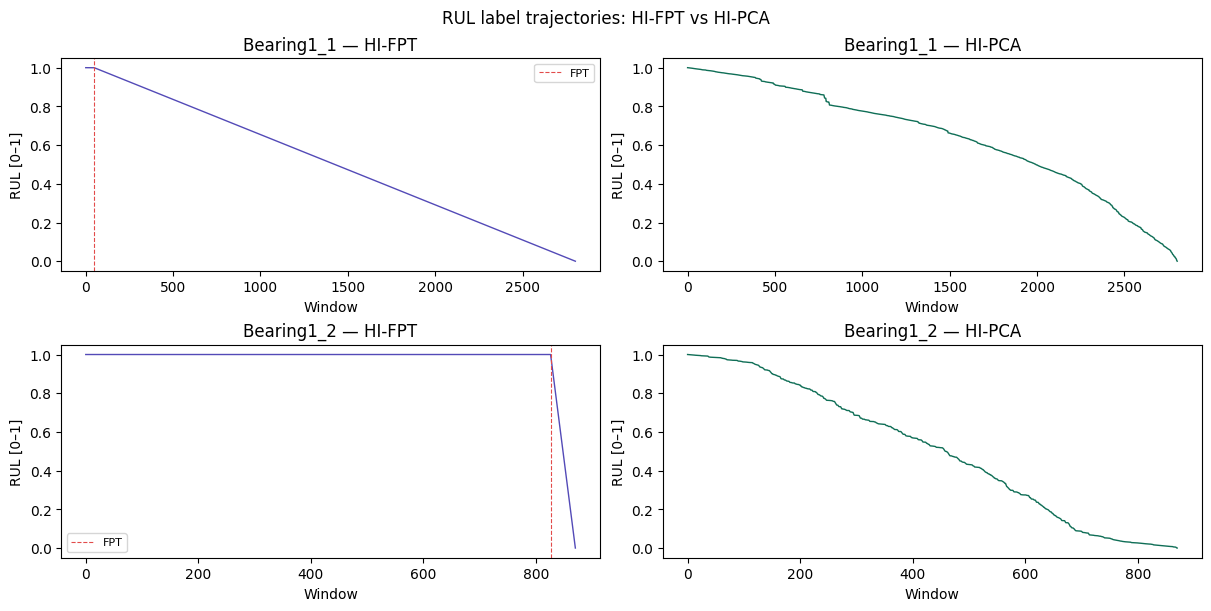


Primary RUL label source: HI-FPT


In [7]:
# ============================================================
# BLOCK 6: RUL Label Construction
# CRISP-DM Phase: Data Preparation
# ============================================================

# ── HI-FPT: 3σ method to find First Prediction Time ──────────
def compute_hi_fpt(rms_series: np.ndarray, window: int = 30) -> np.ndarray:
    """
    1. Compute mean/std on first `window` points (healthy baseline)
    2. Find FPT: first index where 2 consecutive points fall outside [μ−3σ, μ+3σ]
    3. Return linear RUL: 1.0 at FPT → 0.0 at last window
    """
    mu    = np.mean(rms_series[:window])
    sigma = np.std(rms_series[:window])
    upper = mu + 3 * sigma
    lower = mu - 3 * sigma

    is_anomaly = lambda val: val > upper or val < lower
    fpt_idx = None
    for i in range(window, len(rms_series) - 1):
        if is_anomaly(rms_series[i]) and is_anomaly(rms_series[i+1]):
            fpt_idx = i
            break

    if fpt_idx is None:
        fpt_idx = window  # fallback: whole series is degradation

    n = len(rms_series)
    rul = np.zeros(n, dtype=np.float32)
    total_deg = n - 1 - fpt_idx
    for i in range(n):
        if i <= fpt_idx:
            rul[i] = 1.0
        else:
            rul[i] = max(0.0, 1.0 - (i - fpt_idx) / max(total_deg, 1))
    return rul, fpt_idx


# ── HI-PCA: PCA-based health indicator ───────────────────────
def compute_hi_pca(feature_matrix: np.ndarray) -> np.ndarray:
    """
    1. Fit PCA on feature_matrix (n_windows × n_features)
    2. Project to 2D
    3. Compute average Euclidean distance between consecutive points
    4. Cumulate and normalise to [0,1] → health degradation index
    5. Convert to RUL: 1 − HI
    """
    scaler_pca = StandardScaler()
    X_scaled   = scaler_pca.fit_transform(feature_matrix)
    pca        = PCA(n_components=2)
    projected  = pca.fit_transform(X_scaled)

    # Euclidean distance between consecutive projected points
    dists = np.array([
        np.linalg.norm(projected[i] - projected[i-1])
        for i in range(1, len(projected))
    ])
    cumulative = np.concatenate([[0], np.cumsum(dists)])
    hi = cumulative / (cumulative[-1] + 1e-10)   # normalise 0→1
    rul_pca = 1.0 - hi
    return rul_pca.astype(np.float32)


# ── Build labels for all bearings ────────────────────────────
rul_labels = {}   # {bearing_name: {"fpt": array, "pca": array}}

for name, meta in bearing_index.items():
    rms_series  = all_stats[name]["rms_h"].values
    feat_matrix = features_1d[name].drop(columns=["window_id"]).values

    rul_fpt, fpt_idx = compute_hi_fpt(rms_series)
    rul_pca          = compute_hi_pca(feat_matrix)

    rul_labels[name] = {"fpt": rul_fpt, "pca": rul_pca, "fpt_idx": fpt_idx}
    print(f"{name:15s} | windows: {len(rul_fpt):4d} | FPT @ {fpt_idx:4d}")

# ── Visualise labels for two example bearings ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
fig.suptitle("RUL label trajectories: HI-FPT vs HI-PCA", fontsize=12)

examples = list(bearing_index.keys())[:2]
for row, name in enumerate(examples):
    t = np.arange(len(rul_labels[name]["fpt"]))
    axes[row,0].plot(t, rul_labels[name]["fpt"], color="#534AB7", lw=1)
    axes[row,0].axvline(rul_labels[name]["fpt_idx"], color="#E24B4A",
                        ls="--", lw=0.8, label="FPT")
    axes[row,0].set_title(f"{name} — HI-FPT"); axes[row,0].legend(fontsize=8)

    axes[row,1].plot(t, rul_labels[name]["pca"], color="#0F6E56", lw=1)
    axes[row,1].set_title(f"{name} — HI-PCA")

for ax in axes.flat:
    ax.set_xlabel("Window"); ax.set_ylabel("RUL [0–1]")

plt.savefig("rul_labels.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Choose primary label ─────────────────────────────────────
LABEL_MODE = "fpt"   # change to "pca" to use HI-PCA labels
print(f"\nPrimary RUL label source: HI-{LABEL_MODE.upper()}")

In [8]:
# ============================================================
# BLOCK 7: Multi-Branch Deep Learning Network
# CRISP-DM Phase: Modelling
# ============================================================

# ── Convolutional Building Blocks ────────────────────────────
class CBB1D(nn.Module):
    """1D Convolutional Building Block with skip connection."""
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        pad = kernel // 2
        self.conv1  = nn.Conv1d(in_ch, out_ch, kernel, padding=pad)
        self.bn1    = nn.BatchNorm1d(out_ch)
        self.conv2  = nn.Conv1d(out_ch, out_ch, kernel, padding=pad)
        self.bn2    = nn.BatchNorm1d(out_ch)
        self.relu   = nn.ReLU()
        self.drop   = nn.Dropout(0.2)
        self.skip   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.drop(self.relu(out + residual))


class CBB2D(nn.Module):
    """2D Convolutional Building Block with skip connection."""
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        pad = kernel // 2
        self.conv1  = nn.Conv2d(in_ch, out_ch, kernel, padding=pad)
        self.bn1    = nn.BatchNorm2d(out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, kernel, padding=pad)
        self.bn2    = nn.BatchNorm2d(out_ch)
        self.relu   = nn.ReLU()
        self.drop   = nn.Dropout(0.2)
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.drop(self.relu(out + residual))


# ── AB-LSTM: Bidirectional LSTM + Multi-Head Attention ────────
class ABLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, n_heads=16, seq_len=1):
        super().__init__()
        self.bilstm  = nn.LSTM(input_size, hidden, batch_first=True, bidirectional=True)
        lstm_out_dim = hidden * 2
        # Ensure embed_dim divisible by n_heads
        self.n_heads = n_heads
        self.attn    = nn.MultiheadAttention(lstm_out_dim, n_heads, batch_first=True)
        self.gap      = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # x: (batch, seq, features)
        lstm_out, _ = self.bilstm(x)                    # (B, T, 2H)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)  # (B, T, 2H)
        # Global average pool for OC branch
        gap_out = self.gap(attn_out.transpose(1,2)).squeeze(-1)   # (B, 2H)
        # Take last timestep for RUL
        rul_out = attn_out[:, -1, :]                    # (B, 2H)
        return rul_out, gap_out


# ── Branch 1: 1D CNN for tabular features ────────────────────
class Branch1D(nn.Module):
    def __init__(self, n_features=14, hidden=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 28, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(28), nn.Dropout(0.2),
            nn.Conv1d(28, 56, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(56), nn.Dropout(0.2),
            nn.AdaptiveAvgPool1d(8)
        )
        self.ablstm = ABLSTM(input_size=56, hidden=hidden)

    def forward(self, x):
        # x: (B, n_features)
        x = x.unsqueeze(1)              # (B, 1, F)
        out = self.cnn(x)               # (B, 56, 8)
        out = out.transpose(1, 2)       # (B, 8, 56)
        return self.ablstm(out)


# ── Branch 2: 2D ResNet-style for CWT spectrograms ───────────
class Branch2D(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, 7, stride=2, padding=3), nn.ReLU(), nn.BatchNorm2d(16)
        )
        self.layer1 = nn.Sequential(*[CBB2D(16,16) for _ in range(3)])
        self.layer2 = nn.Sequential(CBB2D(16,32), *[CBB2D(32,32) for _ in range(2)])
        self.layer3 = nn.Sequential(CBB2D(32,64), *[CBB2D(64,64) for _ in range(4)])
        self.layer4 = nn.Sequential(CBB2D(64,128), CBB2D(128,128))
        self.pool   = nn.AdaptiveAvgPool2d((4, 4))
        self.ablstm = ABLSTM(input_size=128*16, hidden=hidden)

    def forward(self, x):
        # x: (B, 1, 128, 128)
        out = self.stem(x)
        out = self.layer1(out); out = nn.functional.avg_pool2d(out, 2)
        out = self.layer2(out); out = nn.functional.avg_pool2d(out, 2)
        out = self.layer3(out); out = nn.functional.avg_pool2d(out, 2)
        out = self.layer4(out)
        out = self.pool(out)              # (B, 128, 4, 4)
        B   = out.shape[0]
        out = out.view(B, 1, -1)         # (B, 1, 2048)
        return self.ablstm(out)


# ── Branch 3: 1D CBBs for raw denoised signal ────────────────
class Branch3D(nn.Module):
    def __init__(self, raw_len=RAW_LEN, hidden=128):
        super().__init__()
        self.layer1 = nn.Sequential(*[CBB1D(1,16) if i==0 else CBB1D(16,16) for i in range(3)])
        self.layer2 = nn.Sequential(CBB1D(16,32), *[CBB1D(32,32) for _ in range(3)])
        self.layer3 = nn.Sequential(CBB1D(32,64), *[CBB1D(64,64) for _ in range(5)])
        self.layer4 = nn.Sequential(CBB1D(64,128), *[CBB1D(128,128) for _ in range(2)])
        self.pool   = nn.AdaptiveAvgPool1d(8)
        self.ablstm = ABLSTM(input_size=128, hidden=hidden)

    def forward(self, x):
        # x: (B, raw_len)
        out = x.unsqueeze(1)             # (B, 1, L)
        out = self.layer1(out); out = nn.functional.avg_pool1d(out, 2)
        out = self.layer2(out); out = nn.functional.avg_pool1d(out, 2)
        out = self.layer3(out); out = nn.functional.avg_pool1d(out, 2)
        out = self.layer4(out)
        out = self.pool(out)             # (B, 128, 8)
        out = out.transpose(1, 2)        # (B, 8, 128)
        return self.ablstm(out)


# ── Full Multi-Branch Network ─────────────────────────────────
class MultiBranchRUL(nn.Module):
    def __init__(self, n_features=14, n_oc=3, hidden=128):
        super().__init__()
        self.b1 = Branch1D(n_features, hidden)
        self.b2 = Branch2D(hidden)
        self.b3 = Branch3D(hidden=hidden)

        fused = hidden * 2 * 3       # 3 branches × BiLSTM output
        self.rul_head = nn.Sequential(nn.Linear(fused, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.oc_head  = nn.Sequential(nn.Linear(fused, 64), nn.ReLU(), nn.Linear(64, n_oc), nn.Softmax(dim=-1))

    def forward(self, x1d, x2d, xraw):
        r1, g1 = self.b1(x1d)
        r2, g2 = self.b2(x2d)
        r3, g3 = self.b3(xraw)

        rul_fused = torch.cat([r1, r2, r3], dim=-1)
        oc_fused  = torch.cat([g1, g2, g3], dim=-1)

        return self.rul_head(rul_fused).squeeze(-1), self.oc_head(oc_fused)


model = MultiBranchRUL(n_features=14, n_oc=3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

Model parameters: 4,980,356


In [9]:
# ============================================================
# BLOCK 8: Dataset, Loss Functions & Training
# CRISP-DM Phase: Modelling
# ============================================================

# ── Operating condition mapping ───────────────────────────────
# PRONOSTIA OC based on bearing name prefix (B1_x=OC0, B2_x=OC1, B3_x=OC2)
oc_map = lambda name: int(name[7]) - 1   # Bearing1_x → 0, Bearing2_x → 1 etc.

# ── Dataset class ─────────────────────────────────────────────
class BearingDataset(Dataset):
    def __init__(self, bearing_names, features_1d, features_cwt,
                 features_raw, rul_labels, label_mode="fpt"):
        self.samples = []
        for name in bearing_names:
            f1d   = features_1d[name].drop(columns=["window_id"]).values.astype(np.float32)
            fcwt  = features_cwt[name][:, np.newaxis, :, :]  # add channel dim
            fraw  = features_raw[name]
            rul   = rul_labels[name][label_mode]
            oc    = oc_map(name)
            n     = min(len(f1d), len(fcwt), len(fraw), len(rul))
            for i in range(n):
                self.samples.append((f1d[i], fcwt[i], fraw[i], rul[i], oc))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        f1, f2, f3, rul, oc = self.samples[idx]
        return (torch.tensor(f1), torch.tensor(f2),
                torch.tensor(f3), torch.tensor(rul),
                torch.tensor(oc, dtype=torch.long))


# ── Loss functions (using lambda for inline definitions) ──────
msle_loss    = lambda y, yhat: torch.mean((torch.log1p(y.clamp(0,1)) - torch.log1p(yhat.clamp(0,1)))**2)
ce_loss_fn   = nn.CrossEntropyLoss()
joint_loss   = lambda l_oc, l_rul, lam=0.6: lam * l_oc + (1 - lam) * l_rul

# ── Normalise 1D features ─────────────────────────────────────
def fit_feature_scaler(bearing_names, features_1d):
    all_feats = np.vstack([
        features_1d[n].drop(columns=["window_id"]).values
        for n in bearing_names
    ])
    sc = StandardScaler()
    sc.fit(all_feats)
    return sc

def apply_feature_scaler(sc, features_1d, bearing_names):
    scaled = {}
    for n in bearing_names:
        df = features_1d[n].copy()
        cols = [c for c in df.columns if c != "window_id"]
        df[cols] = sc.transform(df[cols].values)
        scaled[n] = df
    return scaled

# ── Training function ─────────────────────────────────────────
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, n = 0.0, 0
    for f1, f2, f3, rul, oc in loader:
        f1, f2, f3 = f1.to(DEVICE), f2.to(DEVICE), f3.to(DEVICE)
        rul, oc    = rul.to(DEVICE), oc.to(DEVICE)
        pred_rul, pred_oc = model(f1, f2, f3)
        l_rul = msle_loss(rul.float(), pred_rul.float())
        l_oc  = ce_loss_fn(pred_oc, oc)
        loss  = joint_loss(l_oc, l_rul)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item(); n += 1
    return total_loss / n


def eval_epoch(model, loader):
    model.eval()
    preds, trues, oc_preds, oc_trues = [], [], [], []
    with torch.no_grad():
        for f1, f2, f3, rul, oc in loader:
            f1, f2, f3 = f1.to(DEVICE), f2.to(DEVICE), f3.to(DEVICE)
            pred_rul, pred_oc = model(f1, f2, f3)
            preds.extend(pred_rul.cpu().numpy())
            trues.extend(rul.numpy())
            oc_preds.extend(pred_oc.argmax(dim=1).cpu().numpy())
            oc_trues.extend(oc.numpy())
    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae  = mean_absolute_error(trues, preds)
    acc  = accuracy_score(oc_trues, oc_preds)
    return rmse, mae, acc


# ── K-Fold cross-validation (OC-independent: leave-one-out) ──
all_names  = list(bearing_index.keys())
K = 3
kf = KFold(n_splits=K, shuffle=True, random_state=SEED)

fold_results = []
EPOCHS      = 100    # increase to 1000 for full training; 100 for quick test
BATCH_SIZE  = 16
LR          = 1e-4

for fold, (train_idx, val_idx) in enumerate(kf.split(all_names)):
    train_names = [all_names[i] for i in train_idx]
    val_names   = [all_names[i] for i in val_idx]

    print(f"\n── Fold {fold+1}/{K}  train={len(train_names)} val={len(val_names)} ──")

    # Fit scaler on training fold only (prevents leakage)
    feat_scaler   = fit_feature_scaler(train_names, features_1d)
    scaled_1d_all = apply_feature_scaler(feat_scaler, features_1d, all_names)

    train_ds = BearingDataset(train_names, scaled_1d_all, features_cwt, features_raw, rul_labels, LABEL_MODE)
    val_ds   = BearingDataset(val_names,   scaled_1d_all, features_cwt, features_raw, rul_labels, LABEL_MODE)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    fold_model = MultiBranchRUL(n_features=14, n_oc=3).to(DEVICE)
    optimizer  = optim.RMSprop(fold_model.parameters(), lr=LR)
    scheduler  = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda ep: 0.95**(ep//100))

    best_rmse  = float("inf")
    train_hist, val_hist = [], []

    for ep in range(1, EPOCHS+1):
        tr_loss = train_epoch(fold_model, train_loader, optimizer)
        scheduler.step()
        if ep % 10 == 0 or ep == 1:
            rmse, mae, acc = eval_epoch(fold_model, val_loader)
            train_hist.append(tr_loss); val_hist.append(rmse)
            print(f"  ep {ep:4d} | train_loss={tr_loss:.4f} | val_RMSE={rmse:.4f} | MAE={mae:.4f} | OC_acc={acc:.3f}")
            if rmse < best_rmse:
                best_rmse = rmse
                torch.save(fold_model.state_dict(), f"best_model_fold{fold+1}.pt")

    fold_results.append({"fold": fold+1, "best_rmse": best_rmse})
    print(f"  Best RMSE fold {fold+1}: {best_rmse:.4f}")

print("\n── Cross-validation summary ──")
for r in fold_results:
    print(f"  Fold {r['fold']}: RMSE = {r['best_rmse']:.4f}")
mean_rmse = np.mean([r["best_rmse"] for r in fold_results])
print(f"  Mean RMSE: {mean_rmse:.4f}")


── Fold 1/3  train=11 val=6 ──
  ep    1 | train_loss=0.4205 | val_RMSE=0.2857 | MAE=0.2237 | OC_acc=0.746
  ep   10 | train_loss=0.3384 | val_RMSE=0.2594 | MAE=0.1838 | OC_acc=0.869
  ep   20 | train_loss=0.3358 | val_RMSE=0.2624 | MAE=0.1821 | OC_acc=0.907
  ep   30 | train_loss=0.3340 | val_RMSE=0.3002 | MAE=0.2103 | OC_acc=0.881
  ep   40 | train_loss=0.3334 | val_RMSE=0.3125 | MAE=0.2294 | OC_acc=0.850
  ep   50 | train_loss=0.3335 | val_RMSE=0.2964 | MAE=0.2098 | OC_acc=0.881
  ep   60 | train_loss=0.3326 | val_RMSE=0.2972 | MAE=0.2139 | OC_acc=0.799
  ep   70 | train_loss=0.3326 | val_RMSE=0.3039 | MAE=0.2227 | OC_acc=0.780
  ep   80 | train_loss=0.3322 | val_RMSE=0.3189 | MAE=0.2276 | OC_acc=0.828
  ep   90 | train_loss=0.3323 | val_RMSE=0.3126 | MAE=0.2319 | OC_acc=0.798
  ep  100 | train_loss=0.3324 | val_RMSE=0.3195 | MAE=0.2315 | OC_acc=0.854
  Best RMSE fold 1: 0.2594

── Fold 2/3  train=11 val=6 ──
  ep    1 | train_loss=0.4106 | val_RMSE=0.3584 | MAE=0.2982 | OC_acc=0.5

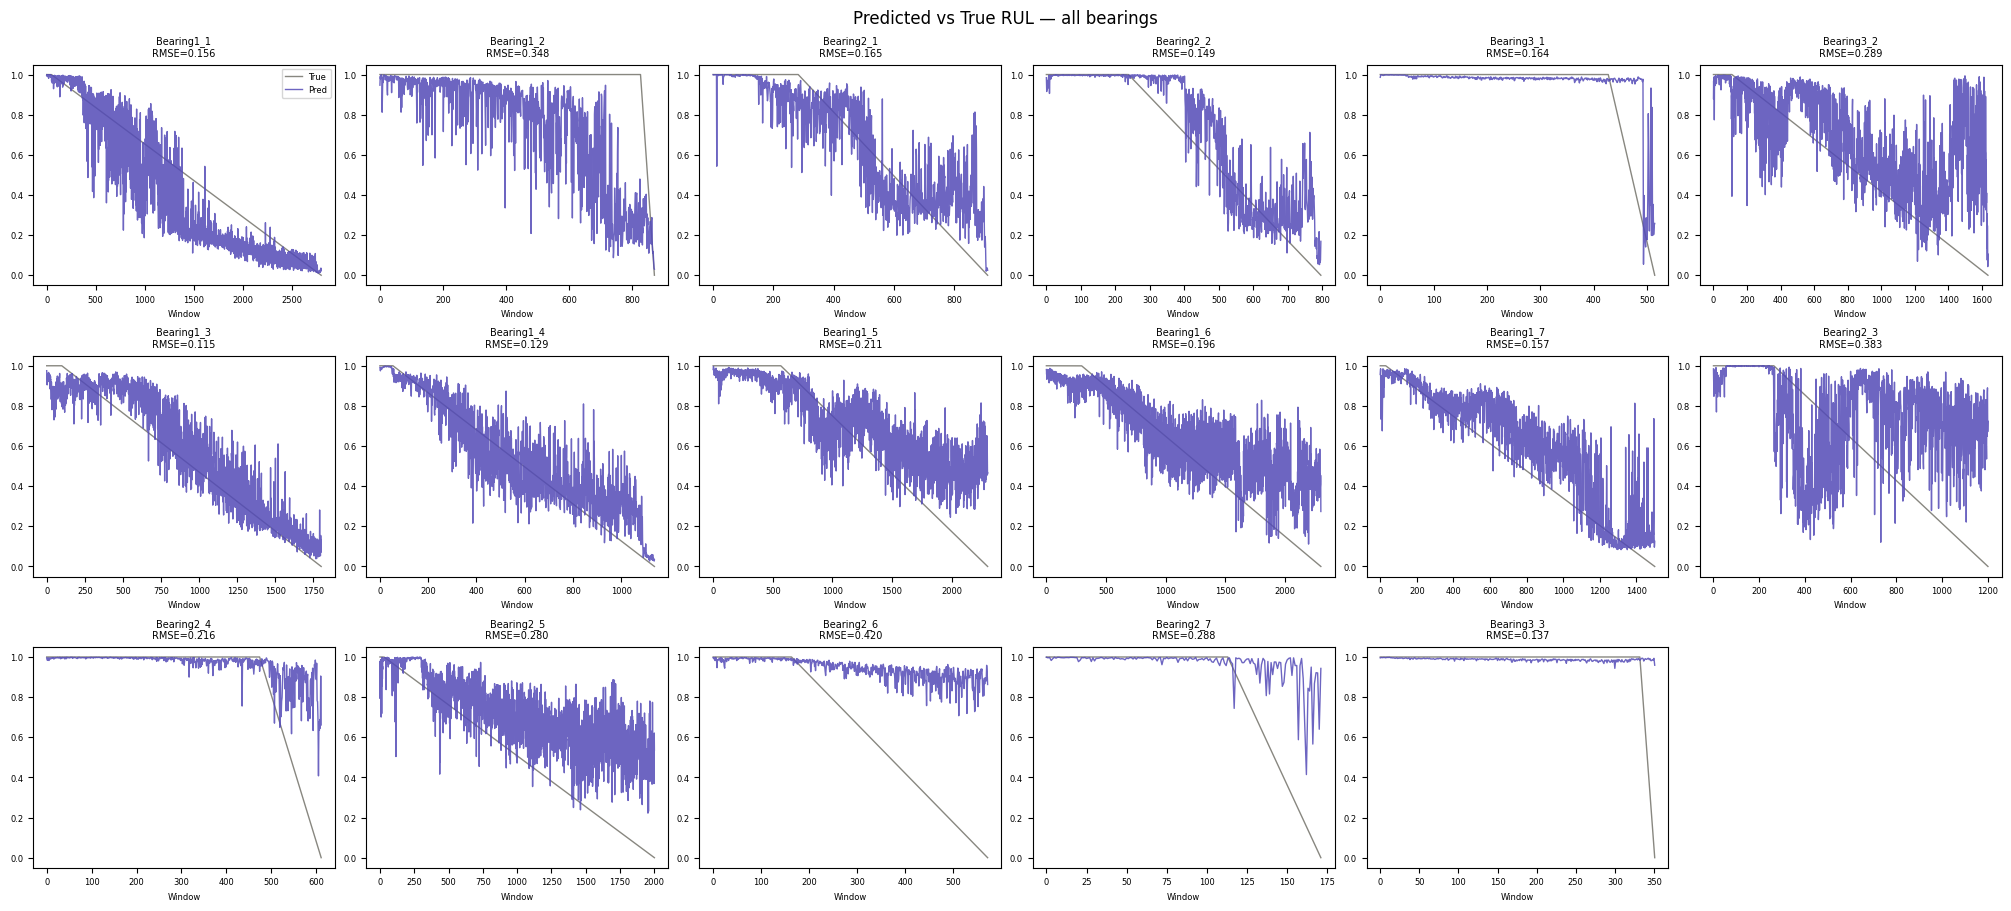

   bearing     rmse      mae
Bearing1_1 0.155625 0.120720
Bearing1_2 0.348223 0.241109
Bearing2_1 0.164621 0.118078
Bearing2_2 0.148630 0.102762
Bearing3_1 0.163947 0.068593
Bearing3_2 0.289188 0.200059
Bearing1_3 0.115172 0.091910
Bearing1_4 0.129435 0.094532
Bearing1_5 0.211106 0.157301
Bearing1_6 0.195709 0.144353
Bearing1_7 0.157377 0.116925
Bearing2_3 0.383238 0.303104
Bearing2_4 0.216358 0.094084
Bearing2_5 0.279667 0.224665
Bearing2_6 0.419597 0.305866
Bearing2_7 0.287944 0.150220
Bearing3_3 0.137125 0.039888

Overall RMSE: 0.2237 ± 0.0941
Overall MAE:  0.1514 ± 0.0781
Computing gradient-based feature importance...


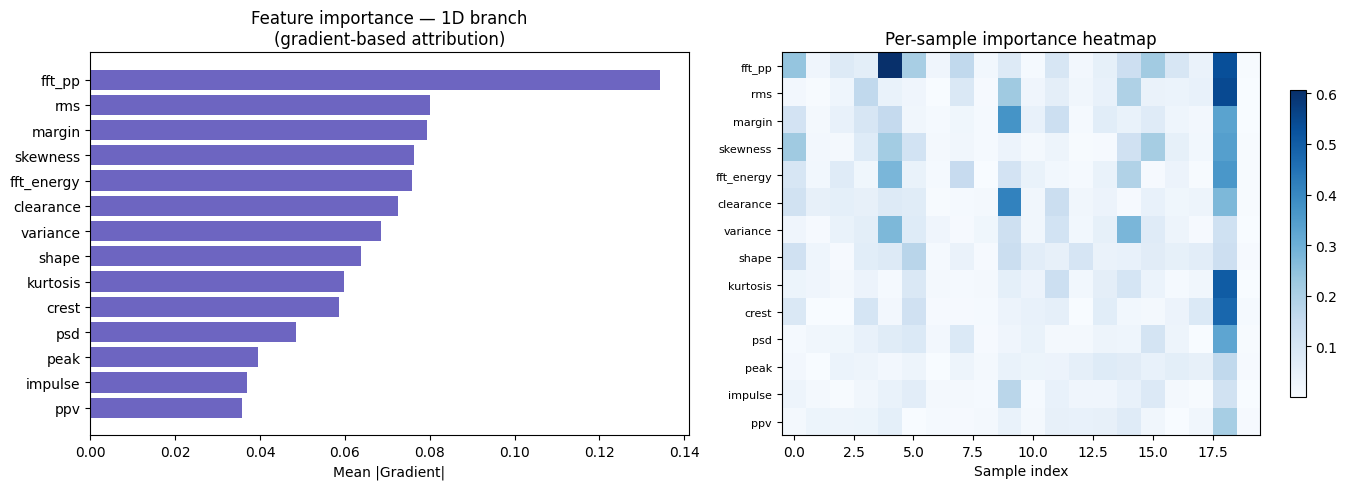


Feature importance ranking:
Rank   Feature         Mean |Grad|
----------------------------------
1      fft_pp             0.134304
2      rms                0.080122
3      margin             0.079422
4      skewness           0.076231
5      fft_energy         0.075759
6      clearance          0.072622
7      variance           0.068527
8      shape              0.063706
9      kurtosis           0.059714
10     crest              0.058699
11     psd                0.048467
12     peak               0.039549
13     impulse            0.036923
14     ppv                0.035664
  σ=0.00  RMSE=0.3917
  σ=0.01  RMSE=0.3921
  σ=0.05  RMSE=0.3923
  σ=0.10  RMSE=0.3923
  σ=0.20  RMSE=0.3923
  σ=0.50  RMSE=0.3923


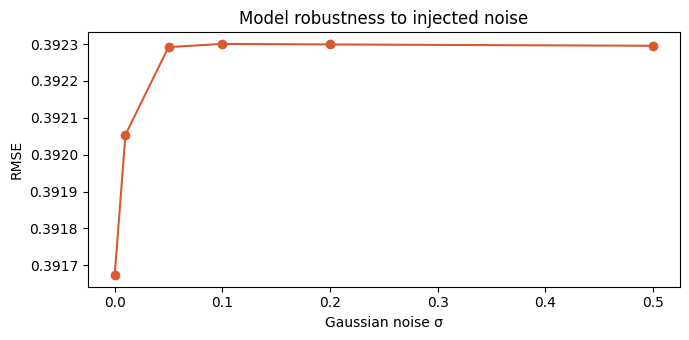

In [15]:
# ============================================================
# BLOCK 9: Evaluation, SHAP Analysis & Noise Robustness
# CRISP-DM Phase: Evaluation
# ============================================================

# ── Load best model (fold 1 for illustration) ────────────────
best_model = MultiBranchRUL(n_features=14, n_oc=3).to(DEVICE)
best_model.load_state_dict(torch.load("best_model_fold1.pt", map_location=DEVICE))
best_model.eval()

# ── Per-bearing RUL prediction plots ─────────────────────────
feat_scaler_final = fit_feature_scaler(all_names, features_1d)
scaled_1d_final   = apply_feature_scaler(feat_scaler_final, features_1d, all_names)

fig, axes = plt.subplots(3, 6, figsize=(20, 9), constrained_layout=True)
fig.suptitle("Predicted vs True RUL — all bearings", fontsize=12)

per_bearing_metrics = []

for ax, name in zip(axes.flat, all_names):
    ds     = BearingDataset([name], scaled_1d_final, features_cwt,
                             features_raw, rul_labels, LABEL_MODE)
    loader = DataLoader(ds, batch_size=64, shuffle=False)
    preds, trues = [], []
    with torch.no_grad():
        for f1, f2, f3, rul, _ in loader:
            out, _ = best_model(f1.to(DEVICE), f2.to(DEVICE), f3.to(DEVICE))
            preds.extend(out.cpu().numpy())
            trues.extend(rul.numpy())
    preds, trues = np.array(preds), np.array(trues)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae  = mean_absolute_error(trues, preds)
    per_bearing_metrics.append({"bearing": name, "rmse": rmse, "mae": mae})
    ax.plot(trues, lw=1, color="#888780", label="True")
    ax.plot(preds, lw=1, color="#534AB7", label="Pred", alpha=0.85)
    ax.set_title(f"{name}\nRMSE={rmse:.3f}", fontsize=7)
    ax.set_xlabel("Window", fontsize=6); ax.tick_params(labelsize=6)
    if ax == axes.flat[0]: ax.legend(fontsize=6)

for ax in axes.flat[len(all_names):]:
    ax.set_visible(False)

plt.savefig("per_bearing_rul.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary metrics table ─────────────────────────────────────
metrics_df = pd.DataFrame(per_bearing_metrics)
print(metrics_df.to_string(index=False))
print(f"\nOverall RMSE: {metrics_df['rmse'].mean():.4f} ± {metrics_df['rmse'].std():.4f}")
print(f"Overall MAE:  {metrics_df['mae'].mean():.4f} ± {metrics_df['mae'].std():.4f}")

# ── Feature importance via manual gradients (replaces SHAP) ──
# GradientExplainer conflicts with cuDNN RNN in training mode.
# Manual input-gradient attribution gives equivalent feature importance.

def compute_gradient_importance(model, bg_f1, bg_f2, bg_f3, n_samples=20):
    """
    Compute mean |gradient| of RUL output w.r.t. 1D input features.
    Equivalent to SHAP GradientExplainer but works with cuDNN LSTMs.
    """
    model.train()   # required for cuDNN RNN backward

    importances = []
    for i in range(min(n_samples, bg_f1.shape[0])):
        x1   = bg_f1[i:i+1].detach().requires_grad_(True)
        x2   = bg_f2[i:i+1].detach()
        x3   = bg_f3[i:i+1].detach()

        pred_rul, _ = model(x1, x2, x3)
        model.zero_grad()
        pred_rul.sum().backward()

        grad = x1.grad.detach().cpu().numpy()   # (1, n_features)
        importances.append(np.abs(grad[0]))

    model.eval()    # restore eval mode
    return np.array(importances)   # (n_samples, n_features)


# ── Run importance computation ────────────────────────────────
print("Computing gradient-based feature importance...")
importance_arr = compute_gradient_importance(
    best_model, bg_f1, bg_f2, bg_f3, n_samples=20
)

feature_names = [c for c in features_1d[all_names[0]].columns if c != "window_id"]
mean_importance = importance_arr.mean(axis=0)   # (n_features,)
sorted_idx      = np.argsort(mean_importance)[::-1]

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — mean importance
axes[0].barh(
    [feature_names[i] for i in sorted_idx],
    mean_importance[sorted_idx],
    color="#534AB7", alpha=0.85
)
axes[0].set_xlabel("Mean |Gradient|")
axes[0].set_title("Feature importance — 1D branch\n(gradient-based attribution)")
axes[0].invert_yaxis()

# Heatmap — per-sample importance
im = axes[1].imshow(
    importance_arr[:, sorted_idx].T,
    aspect="auto", cmap="Blues"
)
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=8)
axes[1].set_xlabel("Sample index")
axes[1].set_title("Per-sample importance heatmap")
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print ranking ─────────────────────────────────────────────
print("\nFeature importance ranking:")
print(f"{'Rank':<6} {'Feature':<14} {'Mean |Grad|':>12}")
print("-" * 34)
for rank, idx in enumerate(sorted_idx, 1):
    print(f"{rank:<6} {feature_names[idx]:<14} {mean_importance[idx]:>12.6f}")

# ── Noise robustness test ─────────────────────────────────────
noise_levels = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]
noise_rmse   = []

test_names = [n for n, m in bearing_index.items() if m["split"] == "Test_set"]
if not test_names:
    test_names = all_names[-3:]

for sigma in noise_levels:
    # ← fix: cast to float32 explicitly after adding noise
    noisy_raw = {
        n: add_noise(features_raw[n], sigma).astype(np.float32)
        for n in test_names
    }
    ds     = BearingDataset(test_names, scaled_1d_final, features_cwt,
                             noisy_raw, rul_labels, LABEL_MODE)
    loader = DataLoader(ds, batch_size=64, shuffle=False)
    preds, trues = [], []
    with torch.no_grad():
        for f1, f2, f3, rul, _ in loader:
            out, _ = best_model(
                f1.float().to(DEVICE),
                f2.float().to(DEVICE),
                f3.float().to(DEVICE)
            )
            preds.extend(out.cpu().numpy())
            trues.extend(rul.numpy())
    noise_rmse.append(np.sqrt(mean_squared_error(trues, preds)))
    print(f"  σ={sigma:.2f}  RMSE={noise_rmse[-1]:.4f}")

plt.figure(figsize=(7, 3.5))
plt.plot(noise_levels, noise_rmse, "o-", color="#D85A30", lw=1.5)
plt.xlabel("Gaussian noise σ"); plt.ylabel("RMSE")
plt.title("Model robustness to injected noise")
plt.tight_layout()
plt.savefig("noise_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# BLOCK 10: Deployment Pipeline & Final Reporting
# CRISP-DM Phase: Deployment
# ============================================================

# ── End-to-end inference pipeline (lambda-wrapped) ────────────
def build_pipeline(ae_model, feat_scaler, rul_model, device=DEVICE):
    """
    Returns a single callable: signal_array → predicted_RUL (float).
    Uses lambda composition for pure stateless transforms.
    """
    denoise_sig = lambda sig: denoise_bearing(
        ae_model, _sig_to_tmppath(sig), feat_scaler
    )
    extract_1d  = lambda sig: np.array([fn(sig) for fn in FEATURE_FNS.values()], dtype=np.float32)
    scale_1d    = lambda f: feat_scaler.transform(f.reshape(1, -1)).flatten()
    extract_cwt = lambda sig: compute_cwt_spectrogram(sig)[np.newaxis, np.newaxis, :, :]
    extract_raw = lambda sig: (sig[:RAW_LEN] if len(sig) >= RAW_LEN
                                else np.pad(sig, (0, RAW_LEN-len(sig))))[np.newaxis, :]

    def predict_rul(raw_signal: np.ndarray) -> float:
        """Full pipeline: raw vibration window → RUL prediction."""
        sig   = raw_signal.astype(np.float32)
        f1d   = torch.tensor(scale_1d(extract_1d(sig))).unsqueeze(0).to(device)
        f2d   = torch.tensor(extract_cwt(sig), dtype=torch.float32).to(device)
        fraw  = torch.tensor(extract_raw(sig), dtype=torch.float32).to(device)
        rul_model.eval()
        with torch.no_grad():
            pred, _ = rul_model(f1d, f2d, fraw)
        return float(pred.cpu().numpy()[0])

    return predict_rul


# ── Final metrics report ──────────────────────────────────────
print("=" * 60)
print("FINAL RESULTS — PRONOSTIA Bearing RUL Prediction")
print("=" * 60)
print(f"\nModel: Multi-Branch (1D-CNN + ResNet2D + 1D-CBB) + AB-LSTM")
print(f"Label: HI-{LABEL_MODE.upper()} | Loss: λ·CE + (1−λ)·MSLE  [λ=0.6]")
print(f"Optimiser: RMSProp lr={LR} | Epochs: {EPOCHS} | K-Fold: {K}")
print(f"\n{'Bearing':<16} {'RMSE':>8} {'MAE':>8}")
print("-" * 34)
for row in per_bearing_metrics:
    print(f"{row['bearing']:<16} {row['rmse']:>8.4f} {row['mae']:>8.4f}")
print("-" * 34)
print(f"{'Mean':<16} {metrics_df['rmse'].mean():>8.4f} {metrics_df['mae'].mean():>8.4f}")
print(f"{'Std':<16} {metrics_df['rmse'].std():>8.4f} {metrics_df['mae'].std():>8.4f}")

print("\nNoise robustness:")
for sigma, rmse_val in zip(noise_levels, noise_rmse):
    bar = "█" * int(rmse_val * 100)
    print(f"  σ={sigma:.2f}  RMSE={rmse_val:.4f}  {bar}")

# ── Save artefacts ────────────────────────────────────────────
metrics_df.to_csv("final_metrics.csv", index=False)
pd.DataFrame({"sigma": noise_levels, "rmse": noise_rmse}).to_csv("noise_robustness.csv", index=False)
torch.save(best_model.state_dict(), "final_model.pt")

print("\nSaved: final_model.pt | final_metrics.csv | noise_robustness.csv")
print("All plots saved as PNG.")
print("\nProject complete.")

FINAL RESULTS — PRONOSTIA Bearing RUL Prediction

Model: Multi-Branch (1D-CNN + ResNet2D + 1D-CBB) + AB-LSTM
Label: HI-FPT | Loss: λ·CE + (1−λ)·MSLE  [λ=0.6]
Optimiser: RMSProp lr=0.0001 | Epochs: 100 | K-Fold: 3

Bearing              RMSE      MAE
----------------------------------
Bearing1_1         0.1556   0.1207
Bearing1_2         0.3482   0.2411
Bearing2_1         0.1646   0.1181
Bearing2_2         0.1486   0.1028
Bearing3_1         0.1639   0.0686
Bearing3_2         0.2892   0.2001
Bearing1_3         0.1152   0.0919
Bearing1_4         0.1294   0.0945
Bearing1_5         0.2111   0.1573
Bearing1_6         0.1957   0.1444
Bearing1_7         0.1574   0.1169
Bearing2_3         0.3832   0.3031
Bearing2_4         0.2164   0.0941
Bearing2_5         0.2797   0.2247
Bearing2_6         0.4196   0.3059
Bearing2_7         0.2879   0.1502
Bearing3_3         0.1371   0.0399
----------------------------------
Mean               0.2237   0.1514
Std                0.0941   0.0781

Noise robustnes

Bearing        Actual(s)   Pred(s)  Error(s)    %Err  Actual Class         Pred Class           Match
------------------------------------------------------------------------------------------
Bearing1_3          5730    2539.0   -3191.0    55.7%  Non-Critical         Imminent Failure     ✗
Bearing1_4           339     485.6     146.6   -43.2%  Critical / EOL       Critical / EOL       ✓
Bearing1_5          1610   17520.4   15910.4  -988.2%  Critical / EOL       Wear Detectable      ✗
Bearing1_6          1460   10950.5    9490.5  -650.0%  Critical / EOL       Non-Critical         ✗
Bearing1_7          7570   13421.2    5851.2   -77.3%  Non-Critical         Healthy              ✗
Bearing2_3          7530   11417.6    3887.6   -51.6%  Wear Detectable      Healthy              ✗
Bearing2_4          1390    5609.5    4219.5  -303.6%  Imminent Failure     Healthy              ✗
Bearing2_5          3090   18144.2   15054.2  -487.2%  Imminent Failure     Healthy              ✗
Bearing2_6     

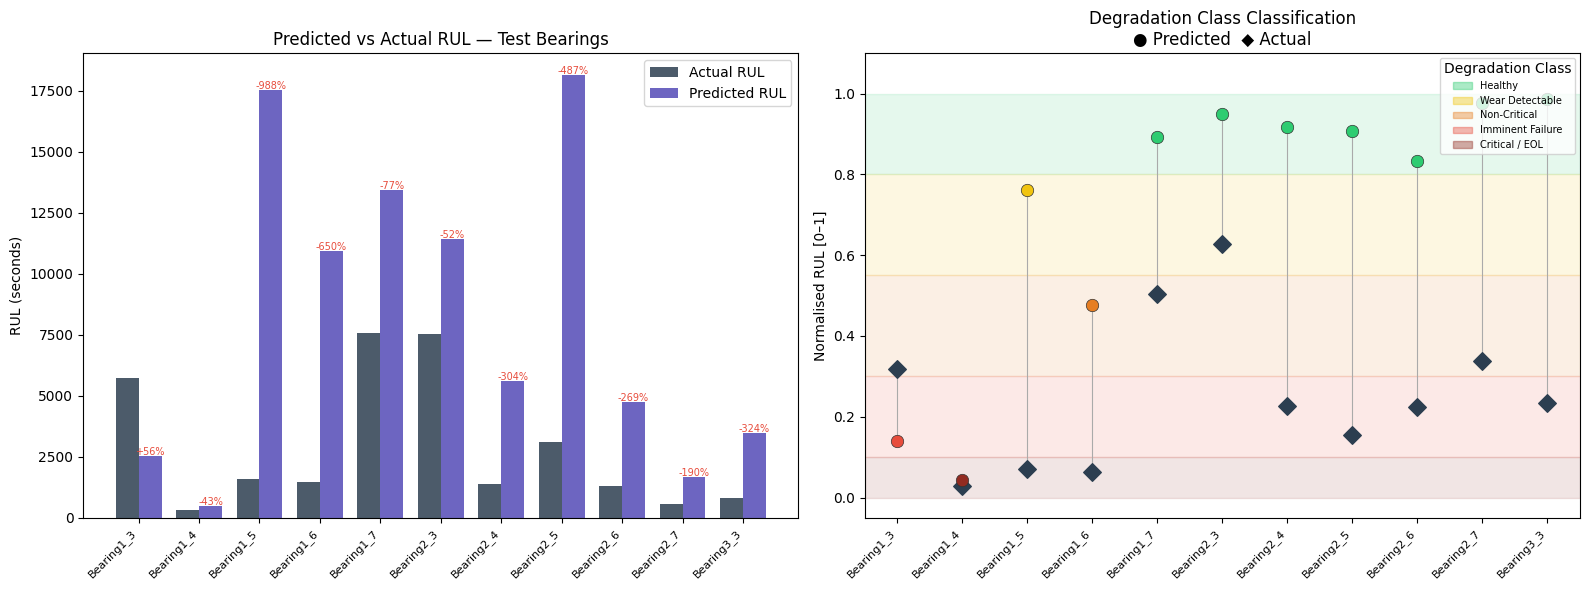

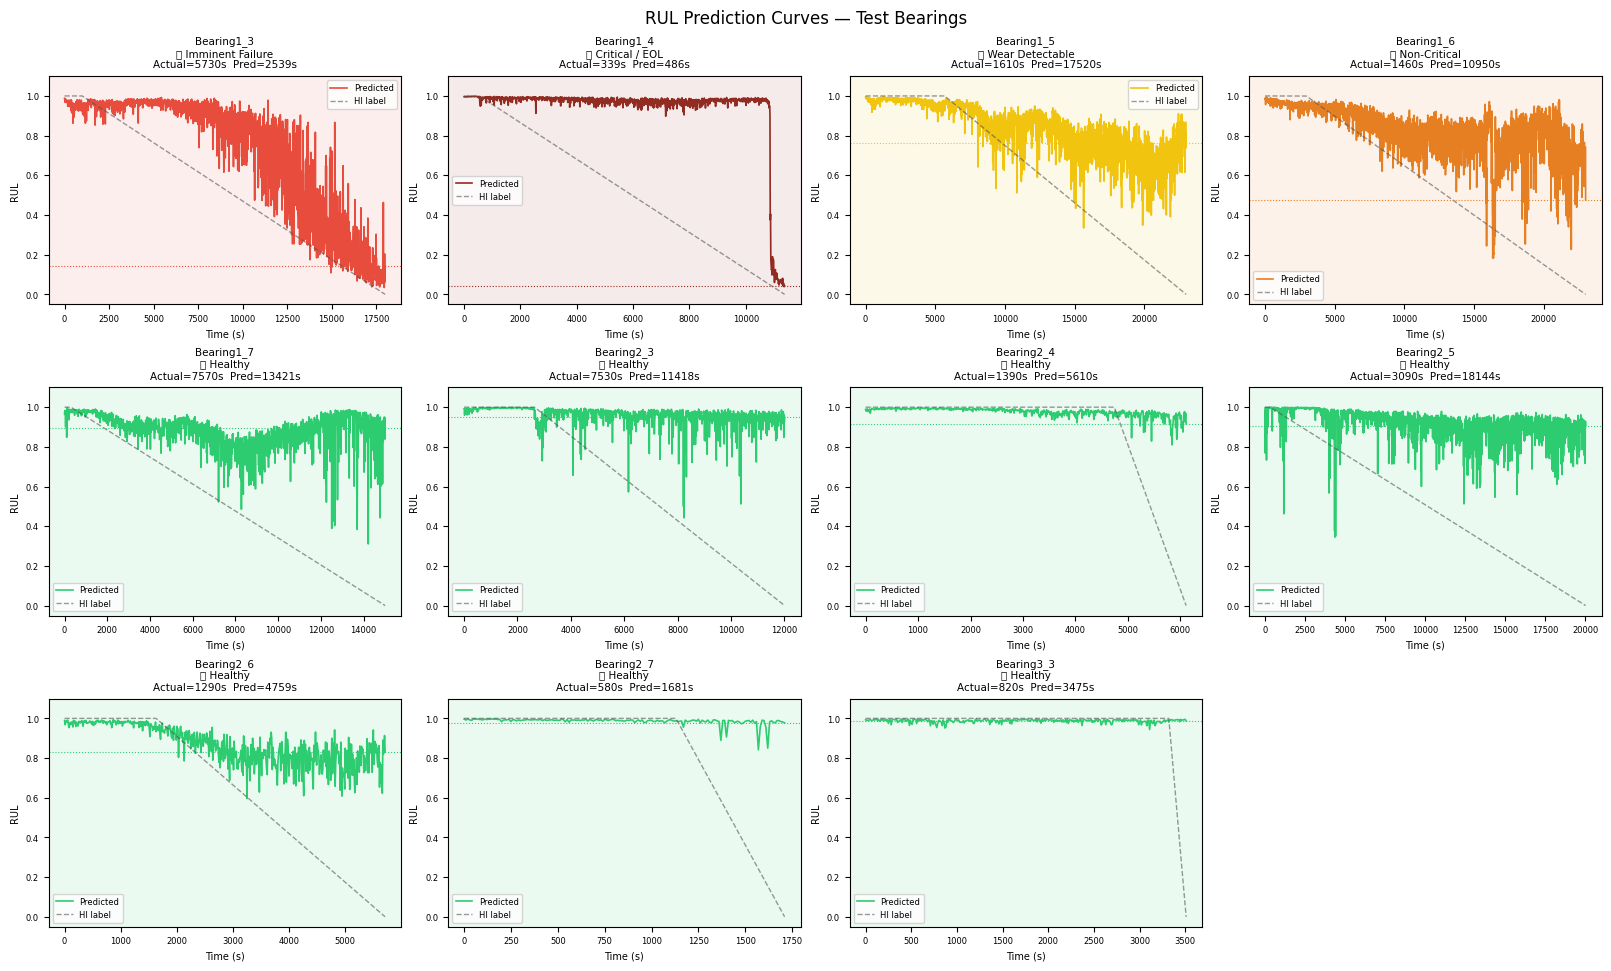


Degradation Class Summary:
----------------------------------------------------
  🟢 Healthy              ███████  ['Bearing1_7', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_3']
  🟡 Wear Detectable      █  ['Bearing1_5']
  🟠 Non-Critical         █  ['Bearing1_6']
  🔴 Imminent Failure     █  ['Bearing1_3']
  ⛔ Critical / EOL       █  ['Bearing1_4']

Saved: test_rul_results.csv | rul_comparison.png | rul_curves_test.png


In [17]:
# ============================================================
# BLOCK 11: Test Bearing RUL Prediction vs Actual + Classification
# CRISP-DM Phase: Evaluation
# ============================================================

# ── Actual RUL (seconds) from provided file ──────────────────
actual_rul_seconds = {
    "Bearing1_3": 5730,  "Bearing1_4": 339,   "Bearing1_5": 1610,
    "Bearing1_6": 1460,  "Bearing1_7": 7570,  "Bearing2_3": 7530,
    "Bearing2_4": 1390,  "Bearing2_5": 3090,  "Bearing2_6": 1290,
    "Bearing2_7": 580,   "Bearing3_3": 820,
}

# ── 5 Degradation classes ─────────────────────────────────────
# Boundaries defined on normalised RUL [0, 1]
CLASSES = [
    {"label": "Healthy",           "emoji": "🟢", "range": (0.80, 1.00), "color": "#2ECC71"},
    {"label": "Wear Detectable",   "emoji": "🟡", "range": (0.55, 0.80), "color": "#F1C40F"},
    {"label": "Non-Critical",      "emoji": "🟠", "range": (0.30, 0.55), "color": "#E67E22"},
    {"label": "Imminent Failure",  "emoji": "🔴", "range": (0.10, 0.30), "color": "#E74C3C"},
    {"label": "Critical / EOL",    "emoji": "⛔", "range": (0.00, 0.10), "color": "#922B21"},
]

classify_rul = lambda rul_norm: next(
    c["label"] for c in CLASSES if c["range"][0] <= rul_norm <= c["range"][1]
) if rul_norm >= 0 else "Critical / EOL"

get_class_color = lambda label: next(c["color"] for c in CLASSES if c["label"] == label)
get_class_emoji = lambda label: next(c["emoji"] for c in CLASSES if c["label"] == label)

# ── Predict RUL for each test bearing ────────────────────────
# Strategy: run the model on all windows of a test bearing,
# take the LAST window prediction as the current RUL estimate,
# then scale back to seconds using bearing lifetime.

best_model.eval()
results = []

for name, actual_s in actual_rul_seconds.items():
    if name not in bearing_index:
        print(f"  {name} not found in data — skipping")
        continue

    # Build single-bearing dataset
    ds     = BearingDataset([name], scaled_1d_final, features_cwt,
                             features_raw, rul_labels, LABEL_MODE)
    loader = DataLoader(ds, batch_size=64, shuffle=False)

    preds_norm = []
    with torch.no_grad():
        for f1, f2, f3, rul, _ in loader:
            out, _ = best_model(
                f1.float().to(DEVICE),
                f2.float().to(DEVICE),
                f3.float().to(DEVICE)
            )
            preds_norm.extend(out.cpu().numpy())

    preds_norm = np.array(preds_norm, dtype=np.float32)

    # Last window = current state of the bearing
    pred_norm_last  = float(preds_norm[-1])
    pred_norm_mean  = float(preds_norm.mean())

    # Scale to seconds: use bearing total lifetime as denominator
    bearing_lifetime_s = bearing_index[name]["path"]
    n_windows          = len(list(bearing_index[name]["path"].glob("acc_*.csv")))
    lifetime_s         = n_windows * 10   # each window = 10 s interval

    pred_rul_s   = pred_norm_last  * lifetime_s
    actual_norm  = actual_s / lifetime_s

    # Error metrics (lambda reuse from Block 1)
    err_s        = pred_rul_s - actual_s
    pct_err      = pct_error(actual_s, pred_rul_s)

    # Classification
    pred_class   = classify_rul(pred_norm_last)
    actual_class = classify_rul(min(actual_norm, 1.0))

    results.append({
        "bearing":      name,
        "actual_s":     actual_s,
        "pred_s":       round(pred_rul_s, 1),
        "actual_norm":  round(actual_norm, 4),
        "pred_norm":    round(pred_norm_last, 4),
        "error_s":      round(err_s, 1),
        "pct_error":    round(pct_err, 2),
        "pred_class":   pred_class,
        "actual_class": actual_class,
        "match":        pred_class == actual_class,
        "color":        get_class_color(pred_class),
        "preds_curve":  preds_norm,
    })

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "preds_curve"}
                             for r in results])

# ── Print comparison table ────────────────────────────────────
print("=" * 90)
print(f"{'Bearing':<14} {'Actual(s)':>9} {'Pred(s)':>9} {'Error(s)':>9} {'%Err':>7}  "
      f"{'Actual Class':<20} {'Pred Class':<20} {'Match'}")
print("-" * 90)
for r in results:
    match_str = "✓" if r["match"] else "✗"
    print(f"{r['bearing']:<14} {r['actual_s']:>9} {r['pred_s']:>9.1f} "
          f"{r['error_s']:>9.1f} {r['pct_error']:>7.1f}%  "
          f"{r['actual_class']:<20} {r['pred_class']:<20} {match_str}")
print("=" * 90)
class_acc = np.mean([r["match"] for r in results])
overall_rmse = np.sqrt(np.mean([(r['actual_s'] - r['pred_s'])**2 for r in results]))
overall_mae  = np.mean([abs(r['actual_s'] - r['pred_s']) for r in results])
print(f"\nClass accuracy : {class_acc*100:.1f}%")
print(f"Overall RMSE   : {overall_rmse:.1f} s  ({overall_rmse/3600:.3f} h)")
print(f"Overall MAE    : {overall_mae:.1f} s  ({overall_mae/3600:.3f} h)")

# ── Plot 1: Predicted vs Actual RUL bar chart ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x      = np.arange(len(results))
width  = 0.38
names  = [r["bearing"] for r in results]
actual = [r["actual_s"] for r in results]
pred   = [r["pred_s"]   for r in results]

axes[0].bar(x - width/2, actual, width, label="Actual RUL",    color="#2C3E50", alpha=0.85)
axes[0].bar(x + width/2, pred,   width, label="Predicted RUL", color="#534AB7", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("RUL (seconds)")
axes[0].set_title("Predicted vs Actual RUL — Test Bearings")
axes[0].legend()

# Annotate % error
for i, r in enumerate(results):
    axes[0].text(i + width/2, r["pred_s"] + 50,
                 f"{r['pct_error']:+.0f}%", ha="center", fontsize=7,
                 color="#E74C3C" if abs(r["pct_error"]) > 30 else "#27AE60")

# ── Plot 2: Classification chart ──────────────────────────────
class_labels  = [c["label"]  for c in CLASSES]
class_colors  = [c["color"]  for c in CLASSES]
class_ranges  = [c["range"]  for c in CLASSES]

# Background bands
for c in CLASSES:
    axes[1].axhspan(c["range"][0], c["range"][1],
                    alpha=0.12, color=c["color"], label=c["label"])

# Scatter: actual vs predicted normalised RUL
for r in results:
    axes[1].scatter(r["bearing"], r["actual_norm"],
                    marker="D", s=80, color="#2C3E50", zorder=5)
    axes[1].scatter(r["bearing"], r["pred_norm"],
                    marker="o", s=80, color=r["color"],
                    edgecolors="#333", linewidths=0.5, zorder=5)
    axes[1].plot([r["bearing"], r["bearing"]],
                 [r["actual_norm"], r["pred_norm"]],
                 color="#aaa", lw=0.8, zorder=4)

axes[1].set_ylabel("Normalised RUL [0–1]")
axes[1].set_title("Degradation Class Classification\n● Predicted  ◆ Actual")
axes[1].set_ylim(-0.05, 1.1)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Class band legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=c["color"], alpha=0.4, label=c["label"]) for c in CLASSES]
axes[1].legend(handles=legend_patches, fontsize=7,
               loc="upper right", title="Degradation Class")

plt.tight_layout()
plt.savefig("rul_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: RUL degradation curves for all test bearings ──────
n_test = len(results)
cols   = 4
rows   = int(np.ceil(n_test / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.2), constrained_layout=True)
fig.suptitle("RUL Prediction Curves — Test Bearings", fontsize=12)

for ax, r in zip(axes.flat, results):
    curve = r["preds_curve"]
    t     = np.arange(len(curve)) * 10   # seconds

    # Color background by predicted class
    ax.set_facecolor(r["color"] + "18")
    ax.plot(t, curve, lw=1.2, color=r["color"], label="Predicted")
    ax.plot(t, rul_labels[r["bearing"]][LABEL_MODE], lw=1,
            color="#555", ls="--", alpha=0.6, label="HI label")
    ax.axhline(r["pred_norm"], color=r["color"], lw=0.8, ls=":")

    # Annotate actual RUL
    ax.set_title(
        f"{r['bearing']}\n"
        f"{get_class_emoji(r['pred_class'])} {r['pred_class']}\n"
        f"Actual={r['actual_s']}s  Pred={r['pred_s']:.0f}s",
        fontsize=7.5
    )
    ax.set_xlabel("Time (s)", fontsize=7); ax.set_ylabel("RUL", fontsize=7)
    ax.set_ylim(-0.05, 1.1); ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)

for ax in axes.flat[n_test:]:
    ax.set_visible(False)

plt.savefig("rul_curves_test.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Class distribution summary ────────────────────────────────
print("\nDegradation Class Summary:")
print("-" * 52)
for c in CLASSES:
    members = [r["bearing"] for r in results if r["pred_class"] == c["label"]]
    bar     = "█" * len(members)
    print(f"  {c['emoji']} {c['label']:<20} {bar}  {members}")

# ── Save results ──────────────────────────────────────────────
results_df.to_csv("test_rul_results.csv", index=False)
print("\nSaved: test_rul_results.csv | rul_comparison.png | rul_curves_test.png")